In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [4]:
# Component values
R = 100          # ohms
L = 50e-3        # henries
C = 10e-6        # farads

# Step input amplitude
Vs = 10          # volts

In [5]:
def rlc_system(t, x):
    i = x[0]
    vC = x[1]
    
    di_dt = (Vs - R*i - vC) / L
    dvC_dt = i / C
    
    return [di_dt, dvC_dt]


In [6]:
t_span = (0, 0.01)  # simulate 10 ms
t_eval = np.linspace(t_span[0], t_span[1], 2000)

# Initial conditions: i(0)=0, vC(0)=0
x0 = [0, 0]

solution = solve_ivp(rlc_system, t_span, x0, t_eval=t_eval)


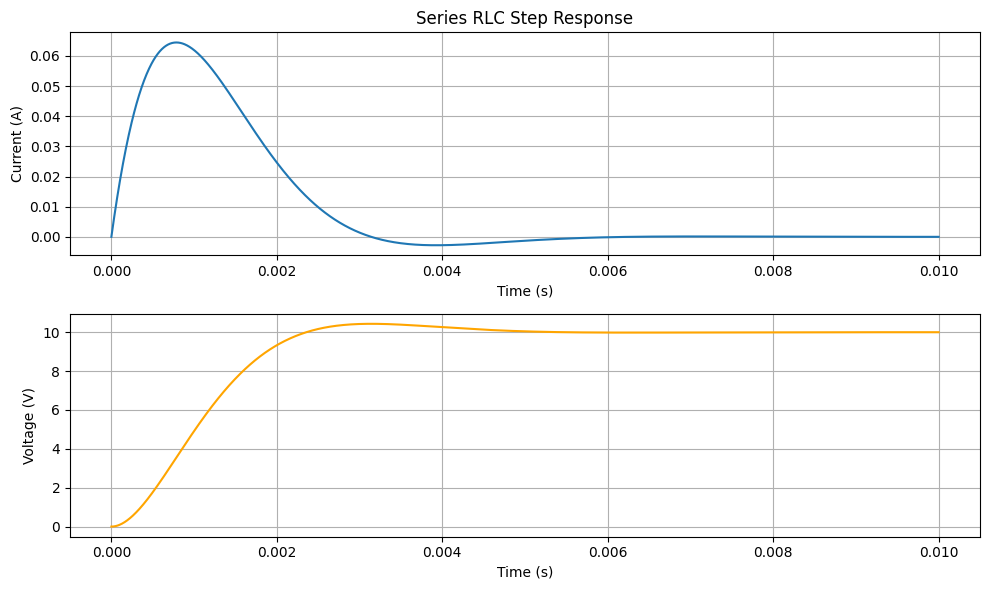

In [7]:
i = solution.y[0]
vC = solution.y[1]
t = solution.t

plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.plot(t, i, label='Current i(t)')
plt.xlabel('Time (s)')
plt.ylabel('Current (A)')
plt.grid(True)
plt.title('Series RLC Step Response')

plt.subplot(2,1,2)
plt.plot(t, vC, color='orange', label='Capacitor Voltage vC(t)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.grid(True)

plt.tight_layout()
plt.show()

This simulation will show:
- Underdamped oscillations in the current
- Capacitor voltage rising and ringing before settling
- Behavior consistent with the damping ratio \zeta \approx 0.707

